In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig

In [2]:
# --- 1. Load Database ---
resin_file = "resin_material_property.csv"
fiber_file = "fiber_material_property.csv"

# Check files
if not os.path.exists(resin_file) or not os.path.exists(fiber_file):
    print("Error: Material files not found. Please upload csv files.")
    df_resin = pd.DataFrame()
    df_fiber = pd.DataFrame()
else:
    df_resin = pd.read_csv(resin_file)
    df_fiber = pd.read_csv(fiber_file)
    print(f"Success: Database loaded. Resin: {len(df_resin)}, Fiber: {len(df_fiber)}")

# --- 2. Enhanced Search Function ---
def get_material_params(name, material_type="fiber"):
    """
    Find material parameters using keyword containment logic.
    """
    # Pre-processing: 轉小寫、去頭尾空白
    query = str(name).lower().strip()
    
    # --- A. Alias Mapping (關鍵字優先對照表) ---
    # 重要: Python 3.7+ 字典有順序性。
    # 請將「特徵較強」的關鍵字放在前面，「通用」的關鍵字放在後面。
    # 這樣如果輸入 "Optical Epoxy"，會先對到 "Optical" 而對應到 CEL。
    
    alias_map = {
        # === 特殊樹脂 (Specific Resins) ===
        # 對應 CEL-400 (透明/光學)
        "cel": "cel",
        "optical": "cel",
        "transparent": "cel",
        "clear": "cel",
        
        # 對應 Plaskon (模塑/封裝/黑色)
        "plaskon": "plaskon",
        "molding": "plaskon",
        "compound": "plaskon",
        "smt": "plaskon",
        "emc": "plaskon",
        
        # === 通用樹脂 (Generic Resins) ===
        # 對應 ELER (標準環氧) - 放在最後當作預設
        "eler": "eler",
        "epoxy": "eler",
        "resin": "eler",
        
        # === 纖維 (Fibers) ===
        "glass": "e-glass",     # Glass -> E-glass
        "fiberglass": "e-glass",
        "t300": "carbon",       # T300 -> Carbon
        "graphite": "carbon"
    }
    
    # 邏輯修正：改為「檢查是否包含」
    mapped_target = None
    for keyword, target in alias_map.items():
        if keyword in query:
            # print(f"   [Alias] Input '{name}' contains keyword '{keyword}' -> Mapped to '{target}'")
            mapped_target = target
            break # 找到第一個(權重最高的)關鍵字就停止，避免被後面的 generic 覆蓋
            
    # 如果有對應到別名，就用別名去搜尋；否則用原始輸入
    final_query = mapped_target if mapped_target else query

    # Select DataFrame
    if material_type == "fiber":
        df = df_fiber
        col_name = df.columns[0] 
    else:
        df = df_resin
        col_name = df.columns[0]
    
    if df.empty:
        return None

    # --- B. Database Search ---
    # 使用最終決定的查詢詞 (final_query) 去資料庫找
    
    match_row = None
    for idx, row in df.iterrows():
        db_name_str = str(row[col_name]).lower().strip()
        
        # 1. 資料庫名稱 包含 查詢詞 (e.g., query="cel" in db="cel-400")
        if final_query in db_name_str:
            match_row = row
            break
            
        # 2. 查詢詞 包含 資料庫名稱 (e.g., query="carbon t300" contains db="carbon")
        # 避免匹配到太短的字串 (長度>2)
        if len(db_name_str) > 2 and db_name_str in final_query:
            match_row = row
            break

    # --- C. Return Result ---
    if match_row is not None:
        match_name = match_row[col_name]
        # print(f"Search Result [{material_type}]: Found '{match_name}'")
        return match_row.values[1:].astype(float)
    else:
        print(f"Warning: No match found for {material_type} name '{name}' (searched as '{final_query}').")
        return None


Success: Database loaded. Resin: 3, Fiber: 2


In [3]:
def get_weave_pattern(style_name="plain"):
    """
    功能: 根據名稱回傳編織矩陣 (0/1)
    輸入 (Input): style_name (str) - plain, twill, satin
    輸出 (Output): numpy array (25,)
    """
    style = style_name.lower().strip()
    
    # 定義 5x5 的樣式 (1 = Weft over Warp, 0 = Warp over Weft)
    patterns = {
        # 平紋 (Plain): 1/1 交錯
        "plain": [
            1, 0, 1, 0, 1,
            0, 1, 0, 1, 0,
            1, 0, 1, 0, 1,
            0, 1, 0, 1, 0,
            1, 0, 1, 0, 1
        ],
        
        # 斜紋 (Twill): 2/2 Twill (這也是標準的，對角線位移)
        # 每一行向右移動一格
        "twill": [ 
            1, 1, 0, 0, 0,  # Row 0
            0, 1, 1, 0, 0,  # Row 1 (Shift 1)
            0, 0, 1, 1, 0,  # Row 2 (Shift 1)
            0, 0, 0, 1, 1,  # Row 3 (Shift 1)
            1, 0, 0, 0, 1   # Row 4 (Wrap around) - 註: 5x5 做 2/2 Twill 邊界會剛好接不上，這是幾何限制
        ],
        
        # 緞紋 (Satin): 5-Harness Satin (Counter = 2)
        # 這是紡織學上標準的 5枚緞紋
        "satin": [ 
            0, 0, 1, 0, 0,  # (0,0)
            1, 0, 0, 0, 0,  # (1,2)
            0, 0, 0, 1, 0,  # (2,4)
            0, 1, 0, 0, 0,  # (3,1)
            0, 0, 0, 0, 1   # (4,3)
        ]
    }
    
    if style in patterns:
        # print(f"Weave Style Selected: {style}")
        return np.array(patterns[style], dtype=float)
    else:
        print(f"Warning: Unknown style '{style}'. Defaulting to 'plain'.")
        return np.array(patterns["plain"], dtype=float)

def plot_weave(vector):
    """
    功能: 畫出編織圖以便確認 (0=白/經, 1=黑/緯)
    """
    matrix = vector.reshape(5, 5)
    plt.figure(figsize=(4, 4))
    # 使用灰階圖: 1(緯)顯示為黑色, 0(經)顯示為白色 (或反過來，看您習慣)
    plt.imshow(matrix, cmap='binary', vmin=0, vmax=1)
    
    # 畫格線
    plt.grid(which='major', color='gray', linestyle='-', linewidth=1)
    plt.xticks(np.arange(-.5, 5, 1)); plt.yticks(np.arange(-.5, 5, 1))
    plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False)
    
    plt.title("Weave Pattern Preview (5x5)")
    plt.show()

In [4]:
def get_geometry_params(user_geo_dict=None):
    """
    功能: 生成幾何參數向量 (含角度轉換與間距自動計算)
    修正: 
      1. 增加對 None 值的檢查
      2. 修正高度限制為固定的 0.1 ~ 0.4 mm，移除與寬度的連動限制
    """
    # 1. 定義預設值 (Defaults)
    defaults = {
        "angle": 90.0,
        "yarn_width": 0.6,
        "yarn_height": 0.2
    }
    
    # 2. 定義別名對照表
    alias_map = {
        "width": "yarn_width",
        "w": "yarn_width",
        "height": "yarn_height",
        "h": "yarn_height",
        "deg": "angle",
        "degree": "angle"
    }

    # 複製預設值作為起點
    user_input = defaults.copy()
    
    if user_geo_dict:
        # A. 預處理: 轉小寫、處理別名
        clean_dict = {}
        for k, v in user_geo_dict.items():
            k_lower = str(k).lower().strip()
            real_key = alias_map.get(k_lower, k_lower)
            clean_dict[real_key] = v
            
        # B. 更新數值 (檢查 val 是否為 None)
        for key, val in clean_dict.items():
            if key in user_input:
                if val is not None:
                    try:
                        user_input[key] = float(val)
                    except (ValueError, TypeError):
                        print(f"Warning: Invalid value for {key}: {val}. Using default.")
                else:
                    pass

    # --- 3. 數值範圍檢查 (修正重點) ---
    u_angle = np.clip(user_input["angle"], 30.0, 90.0)
    
    # 寬度限制: 0.2 ~ 1.0
    width = np.clip(user_input["yarn_width"], 0.2, 1.0)
    
    # 高度限制: 0.1 ~ 0.4 (獨立限制，不依賴寬度)
    height = np.clip(user_input["yarn_height"], 0.1, 0.4)

    # --- 4. 計算模型參數 ---
    # 模型訓練時使用的是與 90 度的夾角差 (0~60)
    model_angle = abs(u_angle - 90.0)
    
    # 間距計算公式 (維持不變)
    # multiplier = 1.5 + (u_angle - 90) * (-0.025)
    # space = width * multiplier
    multiplier = 1.5 + (u_angle - 90.0) * (-0.025)
    space = width * multiplier
    
    # --- 5. 輸出確認 ---
    # print(f"Geometry Processing:")
    # print(f"  - Effective Config: Angle={u_angle}, Width={width}, Height={height}")
    # print(f"  - User Angle: {u_angle:.1f}° -> Model Angle: {model_angle:.1f}°")
    # print(f"  - Space: {space:.3f} mm (Multiplier: {multiplier:.2f}x)")

    ordered_values = [model_angle, width, height, space]
    return np.array(ordered_values, dtype=float)

In [5]:
class PlasticModel(nn.Module):
    def __init__(self):
        super().__init__()

        # --- 1. Image Branch ---
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.dropout1 = nn.Dropout(0.2)
        self.conv3 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=2, stride=2, padding=0)
        self.conv4 = nn.Conv2d(in_channels=2, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
        
        self.flatten = nn.Flatten()
        
        self.img_dense_block = nn.Sequential(
            nn.Linear(18, 960), nn.ReLU(),
            nn.Linear(960, 480), nn.ReLU(),
            nn.Linear(480, 240), nn.ReLU(),
            nn.Linear(240, 120), nn.ReLU()
        )

        # --- 2. Info Branch ---
        self.info_dense_block = nn.Sequential(
            nn.Linear(25, 64), nn.ReLU(),
            nn.Linear(64, 48), nn.ReLU(),
            nn.Linear(48, 36), nn.ReLU(),
            nn.Linear(36, 24), nn.ReLU()
        )

        # --- 3. Combined Path (MLP Fusion) ---
        self.final_dense_block = nn.Sequential(
            # Layer 1: 144 -> 512
            nn.Linear(144, 512),
            nn.ReLU(),
            nn.Dropout(0.1), 
            
            # Layer 2: 512 -> 256
            nn.Linear(512, 256),
            nn.ReLU(),
            
            # Layer 3: 256 -> 128
            nn.Linear(256, 128),
            nn.ReLU(),
           
            # Output Layer: 128 -> 40
            nn.Linear(128, 40)
        )

    def forward(self, img_input, info_input):
        # --- Image Branch ---
        if img_input.shape[-1] == 1: 
            x1 = img_input.permute(0, 3, 1, 2)
        else:
            x1 = img_input
            
        x1 = self.relu(self.conv1(x1))
        x1 = self.relu(self.conv2(x1))
        x1 = self.dropout1(x1)
        x1 = self.relu(self.conv3(x1))
        x1 = self.relu(self.conv4(x1))
        x1 = self.pool1(x1)
        x1 = self.flatten(x1)
        
        x1 = self.img_dense_block(x1) 
        
        # --- Info Branch ---
        x2 = self.info_dense_block(info_input)

        # --- Combined Path ---
        combined = torch.cat((x1, x2), dim=1) 
        output = self.final_dense_block(combined)
        
        return output

In [6]:
# ==========================================
# 2. 模型管理器 (Predictor)
# ==========================================
class Predictor:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Initializing Predictor on {self.device}...")
        
        # 定義檔案路徑 (請確認檔名與您截圖中的一致)
        self.paths = {
            "pla_model": "plastic_model_pytorch.pth",
            "pla_in": "plastic_input_scaler.pkl",
            "pla_out": "plastic_output_scaler.pkl"
        }

        # --- 載入 Plastic System (塑性) ---
        try:
            self.model_pla = PlasticModel().to(self.device)
            # 載入您剛剛訓練好的權重
            self.model_pla.load_state_dict(torch.load(self.paths["pla_model"], map_location=self.device))
            self.model_pla.eval() # 確保 Dropout 關閉
            self.scaler_pla_in = joblib.load(self.paths["pla_in"])
            self.scaler_pla_out = joblib.load(self.paths["pla_out"])
            print("Plastic Model loaded.")
        except Exception as e:
            print(f"Error loading Plastic Model: {e}")
            self.model_pla = None

    def predict(self, weave_style, geo_dict, resin_name, fiber_name):
        # 1. 獲取參數
        weave_vec = get_weave_pattern(weave_style) 
        geo_vec = get_geometry_params(geo_dict)    
        fiber_vec = get_material_params(fiber_name, "fiber") 
        resin_vec_full = get_material_params(resin_name, "resin")

        if resin_vec_full is None or fiber_vec is None:
            return {"error": "Material not found"}

        results = {}

        
        # 2. 預測 - 塑性模型
        if self.model_pla:
            # 切片: 取全部 (包含塑性參數)
            resin_vec_pla = resin_vec_full[:] 
            info_raw = np.concatenate([geo_vec, resin_vec_pla, fiber_vec])
            
            # 預處理
            info_scaled = self.scaler_pla_in.transform(info_raw.reshape(1, -1))
            img_tensor = torch.tensor(weave_vec.reshape(1, 1, 5, 5), dtype=torch.float32).to(self.device)
            info_tensor = torch.tensor(info_scaled, dtype=torch.float32).to(self.device)
            
            with torch.no_grad():
                pred_scaled = self.model_pla(img_tensor, info_tensor)
                pred_final = self.scaler_pla_out.inverse_transform(pred_scaled.cpu().numpy())
            results["plastic"] = pred_final.flatten()
            
        return results



In [7]:
def find_smart_yield_point(stress, strain):
    """
    自動偵測雙線性轉折點 (Knee Point)。
    優先使用雙線交點法 (Bilinear Intersection)，失敗則退回微量偏差法。
    
    Returns:
        (yield_stress, yield_strain, method_name, debug_info)
    """
    # 資料太少直接跳過
    if len(strain) < 5: 
        return None, None, "Data too short", {}
    
    # --- 方法 A: 雙線性交點法 (Bilinear Intersection) ---
    # 1. 擬合第一段 (彈性段): 取前 20% 點
    n_start = max(3, int(len(strain) * 0.2))
    slope1, intercept1 = np.polyfit(strain[:n_start], stress[:n_start], 1)
    
    # 2. 擬合第二段 (塑性段): 取後 30% 點
    n_end = max(3, int(len(strain) * 0.3))
    slope2, intercept2 = np.polyfit(strain[-n_end:], stress[-n_end:], 1)
    
    debug_info = {
        "slope_elastic": slope1,
        "slope_plastic": slope2,
        "intercept_plastic": intercept2
    }

    # 3. 檢查斜率是否有明顯變化 (避免抓到純直線)
    # 如果前後斜率差異 > 1% 才算有轉折
    if abs(slope1 - slope2) / (abs(slope1) + 1e-9) > 0.01:
        # 解聯立方程式: m1*x + c1 = m2*x + c2
        # x = (c2 - c1) / (m1 - m2)
        yield_strain = (intercept2 - intercept1) / (slope1 - slope2)
        yield_stress = slope1 * yield_strain + intercept1
        
        # 檢查交點是否在合理範圍 (允許稍微超出模擬邊界)
        if 0 <= yield_strain <= np.max(strain) * 1.5:
            return yield_stress, yield_strain, "Bilinear Intersection", debug_info

    # --- 方法 B: 微量偏差法 (Micro-Offset 0.002%) ---
    # 備案：如果交點法失敗，嘗試用極小的 offset
    micro_offset = 0.00002 # 0.002%
    
    offset_line = slope1 * (strain - micro_offset) + intercept1
    diff = stress - offset_line
    idx = np.where(diff < 0)[0]
    
    if len(idx) > 0:
        cross_idx = idx[0]
        return stress[cross_idx], strain[cross_idx], "0.002% Offset", debug_info

    return None, None, "No Yield Found (Linear)", debug_info

In [8]:
class CompositeEnvPPO:
    def __init__(self, predictor, df_resin, df_fiber):
        self.predictor = predictor
        
        # --- 1. 定義選項清單 ---
        self.weave_options = ["plain", "twill", "satin"]
        self.resin_options = df_resin.iloc[:, 0].astype(str).tolist()
        self.fiber_options = df_fiber.iloc[:, 0].astype(str).tolist()
        
        self.resin_props_matrix = df_resin.iloc[:, 1:].astype(float).values
        self.fiber_props_matrix = df_fiber.iloc[:, 1:].astype(float).values
        
        print(f"PPO Env Initialized: {len(self.resin_options)} resins, {len(self.fiber_options)} fibers.")

        # --- 2. 動作空間定義 (PPO 混合動作概念) ---
        # 注意：我們不需要 Gym 的 Action Space，這裡純粹記錄維度供 Agent 參考
        self.action_dims = {
            "weave": len(self.weave_options), # 離散 (Discrete)
            "resin": len(self.resin_options), # 離散 (Discrete)
            "fiber": len(self.fiber_options), # 離散 (Discrete)
            "geo": 3                          # 連續 (Continuous: Angle, Width, Height)
        }

        # --- 3. 狀態空間維度 ---
        self.n_resin_props = self.resin_props_matrix.shape[1]
        self.n_fiber_props = self.fiber_props_matrix.shape[1]
        
        # 狀態順序：Target(3) + Weave_OneHot(3) + Geo(4) + Resin(Props+OneHot) + Fiber(Props+OneHot)
        self.state_dim = (3 + len(self.weave_options) + 4 + 
                          (self.n_resin_props + len(self.resin_options)) + 
                          (self.n_fiber_props + len(self.fiber_options)))
        
        print(f"State Dimension: {self.state_dim}")

        # --- 4. 幾何參數真實邊界 ---
        self.geo_min = np.array([30.0, 0.2, 0.1])
        self.geo_max = np.array([90.0, 1.0, 0.4])
        
        # --- 5. 目標縮放尺度 (Reward Scaling) ---
        self.target_scales = {
            0: 1e-3,   # Energy
            1: 1e-10,  # Stiffness 
            2: 1e-6    # Yield
        }

        # --- 6. 內部變數 ---
        self.cur_weave_idx = 0
        self.cur_resin_idx = 0
        self.cur_fiber_idx = 0
        
        # PPO 專用：內部儲存 [-1, 1] 的正規化幾何數值
        self.cur_geo_norm = np.zeros(3) 
        self.cur_geo_real = np.zeros(3) 
        
        self.current_target = 0 
        self.steps = 0
        self.max_steps = 30 # PPO 單局不用太長
        self.best_score_episode = 0 

    def reset(self, target_type="max_energy"):
        # 1. 隨機初始離散選項
        self.cur_weave_idx = random.randint(0, len(self.weave_options)-1)
        self.cur_resin_idx = random.randint(0, len(self.resin_options)-1)
        self.cur_fiber_idx = random.randint(0, len(self.fiber_options)-1)
        
        # 2. 隨機初始連續幾何 (在 [-1, 1] 之間)
        self.cur_geo_norm = np.random.uniform(-1.0, 1.0, size=(3,))
        self._update_real_geo() # 計算真實物理幾何數值
        
        # 3. 設定目標
        target_map = {"max_energy": 0, "max_stiffness": 1, "max_yield": 2}
        self.current_target = target_map.get(target_type, 0)
        
        self.steps = 0
        
        # 4. 初始化分數基準
        raw_score = self._calculate_physics_score()
        scale = self.target_scales.get(self.current_target, 1.0)
        
        self.prev_score_norm = raw_score * scale
        self.best_score_episode = self.prev_score_norm
        
        return self._get_observation()

    def step(self, action_dict):
        """
        接收 PPO Agent 傳來的混合動作字典
        action_dict = {
            'weave': int,
            'resin': int,
            'fiber': int,
            'geo': np.array([angle_norm, width_norm, height_norm]) # range: [-1, 1]
        }
        """
        self.steps += 1
        
        # --- 1. 執行動作 (直接覆蓋為絕對值) ---
        self.cur_weave_idx = int(action_dict['weave'])
        self.cur_resin_idx = int(action_dict['resin'])
        self.cur_fiber_idx = int(action_dict['fiber'])
        
        # 裁剪幾何數值確保在 [-1, 1] 內
        self.cur_geo_norm = np.clip(action_dict['geo'], -1.0, 1.0)
        self._update_real_geo() # 將 [-1,1] 轉回真實的物理維度
        
        # --- 2. 呼叫預測模型 ---
        raw_score = self._calculate_physics_score()
        
        # --- 3. PPO 獎勵計算 (純絕對分數版) ---
        scale = self.target_scales.get(self.current_target, 1.0)
        norm_score = raw_score * scale
        
        # 1. 核心邏輯：獎勵就是當前表現的絕對分數！
        # 表現越好，每一步拿到的分就越高。模型為了總分最大化，會盡快找到最高分並保持住。
        reward = norm_score
        
        # 2. 失敗懲罰
        # 如果物理計算失敗或分數極低，給予明確懲罰
        if raw_score <= 1e-9:
            reward = -5.0 
            
        # 3. 數值裁剪 (Clipping)
        # 確保極端情況下不會把神經網路的梯度算爆
        reward = np.clip(reward, -5.0, 10.0)

        self.prev_score_norm = norm_score
        done = self.steps >= self.max_steps
        
        # [關鍵] 把 Raw Score 放在 Info 裡傳出去，供 Log 與繪圖使用
        info = {
            "raw_score": raw_score,
            "real_geo": self.cur_geo_real.copy()
        }
        
        return self._get_observation(), reward, done, info

    def _update_real_geo(self):
        """將 [-1, 1] 的神經網路輸出，線性映射回真實物理範圍"""
        self.cur_geo_real = self.geo_min + 0.5 * (self.cur_geo_norm + 1.0) * (self.geo_max - self.geo_min)

    def _get_observation(self):
        # 1. Target (One-Hot)
        target_vec = np.zeros(3)
        target_vec[self.current_target] = 1.0
        
        # 2. Weave (One-Hot)
        s_weave_oh = np.zeros(len(self.weave_options))
        s_weave_oh[self.cur_weave_idx] = 1.0
        
        # 3. Geometry (包含 Space 計算，維持神經網路友善範圍)
        angle_real, width_real, height_real = self.cur_geo_real
        multiplier = 1.5 + (angle_real - 90.0) * (-0.025)
        space_real = width_real * multiplier
        
        # 將 space 也稍微縮小一點放進狀態裡，或直接用 norm 值
        s_geo = np.array([
            self.cur_geo_norm[0], 
            self.cur_geo_norm[1], 
            self.cur_geo_norm[2], 
            space_real / 2.0 # 簡單除以 2 讓數值大概落在 0~1 之間
        ])
        
        # 4. Resin (Properties + One-Hot)
        s_resin_props = np.log10(self.resin_props_matrix[self.cur_resin_idx] + 1e-9)
        s_resin_oh = np.zeros(len(self.resin_options))
        s_resin_oh[self.cur_resin_idx] = 1.0
        
        # 5. Fiber (Properties + One-Hot)
        s_fiber_props = np.log10(self.fiber_props_matrix[self.cur_fiber_idx] + 1e-9)
        s_fiber_oh = np.zeros(len(self.fiber_options))
        s_fiber_oh[self.cur_fiber_idx] = 1.0
        
        # 依序串接：Target -> Weave -> Geo -> Resin -> Fiber
        state = np.concatenate([
            target_vec,
            s_weave_oh,
            s_geo,
            s_resin_props, s_resin_oh,
            s_fiber_props, s_fiber_oh
        ])
        return state.astype(np.float32)

    def _calculate_physics_score(self):
        weave_name = self.weave_options[self.cur_weave_idx]
        resin_name = self.resin_options[self.cur_resin_idx]
        fiber_name = self.fiber_options[self.cur_fiber_idx]
        
        # PPO 必須使用還原後的真實數值去跑模擬
        angle, width, height = self.cur_geo_real
        
        geo_dict = {
            "angle": angle,
            "width": width,
            "height": height
        }
        
        result = self.predictor.predict(weave_name, geo_dict, resin_name, fiber_name)
        
        if "error" in result or "plastic" not in result:
            return 0.0
            
        plastic_data = result["plastic"]
        stress = plastic_data[0::2]
        strain = plastic_data[1::2]
        
        val = 0.0
        
        if self.current_target == 0: # Max Energy
            val = np.trapezoid(stress, strain)
        elif self.current_target == 1: # Max Stiffness
            if len(strain) > 1:
                val = (stress[1] - stress[0]) / (strain[1] - strain[0])
        elif self.current_target == 2: # Max Yield
            try:
                y_str, _, _, _ = find_smart_yield_point(stress, strain) # 確保外部有此函數
                if y_str: val = y_str
            except:
                val = 0.0
                
        return val

## 測試環境

In [9]:
predictor = Predictor()
env = CompositeEnvPPO(predictor, df_resin, df_fiber)

Initializing Predictor on cuda...
Plastic Model loaded.
PPO Env Initialized: 3 resins, 2 fibers.
State Dimension: 36


In [10]:
def test_ppo_env_angle_increment(env):
    print("="*50)
    print("啟動 PPO 環境測試：固定其他參數，僅遞增角度")
    print("="*50)

    # 1. 重置環境，指定一個測試目標 (例如 max_energy)
    state = env.reset(target_type="max_energy")
    
    # 2. 設定固定的離散選項與幾何參數
    fixed_weave = 0        # 固定選第 0 個編織樣式 (例如 plain)
    fixed_resin = 0        # 固定選第 0 個樹脂
    fixed_fiber = 0        # 固定選第 0 個纖維
    fixed_width_norm = 0.0 # 寬度正規化設為 0.0 (對應真實範圍的中間值)
    fixed_height_norm = 0.0# 高度正規化設為 0.0 (對應真實範圍的中間值)
    
    total_steps = 20
    
    for i in range(total_steps):
        # 3. 計算遞增的角度正規化數值
        # 讓 angle_norm 從 -1.0 均勻遞增到 1.0
        angle_norm = 1.0 - (i / (total_steps - 1)) * 2.0
        
        # 4. 組裝 PPO 格式的動作字典 (Action Dict)
        action_dict = {
            'weave': fixed_weave,
            'resin': fixed_resin,
            'fiber': fixed_fiber,
            'geo': np.array([angle_norm, fixed_width_norm, fixed_height_norm])
        }
        
        # 5. 步進環境
        next_state, reward, done, info = env.step(action_dict)
        
        # 6. 從 info 中提取真實物理資訊進行觀察
        real_geo = info['real_geo']
        real_angle = real_geo[0]   # 觀察真實角度變化
        real_width = real_geo[1]   # 確認寬度是否固定
        raw_score = info['raw_score']
        
        # 輸出結果，檢查映射是否正確 (應該會看到角度從 30 增加到 90)
        print(f"Step {i+1:2d} | 動作(Norm): {angle_norm:5.2f} -> 真實角度: {real_angle:4.1f}° | "
              f"寬度: {real_width:4.2f} | 物理分數: {raw_score:.4e} | RL 獎勵: {reward:6.2f}")
        
        # 如果環境提早結束，則跳出迴圈
        if done:
            print("環境已達到最大步數 (Done)。")
            break


In [11]:
# 執行測試
test_ppo_env_angle_increment(env)

啟動 PPO 環境測試：固定其他參數，僅遞增角度
Step  1 | 動作(Norm):  1.00 -> 真實角度: 90.0° | 寬度: 0.60 | 物理分數: 4.2419e+03 | RL 獎勵:   4.24
Step  2 | 動作(Norm):  0.89 -> 真實角度: 86.8° | 寬度: 0.60 | 物理分數: 4.1857e+03 | RL 獎勵:   4.19
Step  3 | 動作(Norm):  0.79 -> 真實角度: 83.7° | 寬度: 0.60 | 物理分數: 4.1335e+03 | RL 獎勵:   4.13
Step  4 | 動作(Norm):  0.68 -> 真實角度: 80.5° | 寬度: 0.60 | 物理分數: 4.0961e+03 | RL 獎勵:   4.10
Step  5 | 動作(Norm):  0.58 -> 真實角度: 77.4° | 寬度: 0.60 | 物理分數: 4.0632e+03 | RL 獎勵:   4.06
Step  6 | 動作(Norm):  0.47 -> 真實角度: 74.2° | 寬度: 0.60 | 物理分數: 4.0419e+03 | RL 獎勵:   4.04
Step  7 | 動作(Norm):  0.37 -> 真實角度: 71.1° | 寬度: 0.60 | 物理分數: 4.0471e+03 | RL 獎勵:   4.05
Step  8 | 動作(Norm):  0.26 -> 真實角度: 67.9° | 寬度: 0.60 | 物理分數: 4.1592e+03 | RL 獎勵:   4.16
Step  9 | 動作(Norm):  0.16 -> 真實角度: 64.7° | 寬度: 0.60 | 物理分數: 4.2954e+03 | RL 獎勵:   4.30
Step 10 | 動作(Norm):  0.05 -> 真實角度: 61.6° | 寬度: 0.60 | 物理分數: 4.4355e+03 | RL 獎勵:   4.44
Step 11 | 動作(Norm): -0.05 -> 真實角度: 58.4° | 寬度: 0.60 | 物理分數: 4.5889e+03 | RL 獎勵:   4.59
Step 12 | 動作(Norm)

In [12]:
def test_ppo_env_fully_random(env):
    print("="*65)
    print("啟動 PPO 環境測試：全隨機動作 (觀察 Reward 的正負變化)")
    print("="*65)

    # 1. 重置環境，指定一個測試目標
    state = env.reset(target_type="max_energy")
    
    total_steps = 20
    
    for i in range(total_steps):
        # 2. 隨機生成所有的離散與連續動作
        rand_weave = random.randint(0, len(env.weave_options) - 1)
        rand_resin = random.randint(0, len(env.resin_options) - 1)
        rand_fiber = random.randint(0, len(env.fiber_options) - 1)
        
        # 幾何參數：產生 3 個落在 [-1.0, 1.0] 之間的隨機浮點數
        rand_geo_norm = np.random.uniform(-1.0, 1.0, size=(3,))
        
        # 3. 組裝 PPO 格式的動作字典
        action_dict = {
            'weave': rand_weave,
            'resin': rand_resin,
            'fiber': rand_fiber,
            'geo': rand_geo_norm
        }
        
        # 4. 步進環境
        next_state, reward, done, info = env.step(action_dict)
        
        # 5. 提取資訊進行觀察
        real_geo = info['real_geo']
        raw_score = info['raw_score']
        
        weave_name = env.weave_options[rand_weave]
        # print(env.resin_options[rand_resin])
        # print(env.fiber_options[rand_fiber])
        
        # 印出結果，特別觀察分數與 Reward 的對應關係
        print(f"Step {i+1:2d} | 編織: {weave_name:5s} | 幾何(真): [{real_geo[0]:4.1f}°, {real_geo[1]:4.2f}, {real_geo[2]:4.2f}]")
        print(f"        | 分數: {raw_score:.4e} | RL 獎勵: {reward:6.2f}")
        print("-" * 65)
        
        if done:
            print("環境已達到最大步數 (Done)。")
            break



In [13]:
# 執行測試
test_ppo_env_fully_random(env)

啟動 PPO 環境測試：全隨機動作 (觀察 Reward 的正負變化)
Step  1 | 編織: plain | 幾何(真): [50.7°, 0.46, 0.38]
        | 分數: 3.7235e+03 | RL 獎勵:   3.72
-----------------------------------------------------------------
Step  2 | 編織: twill | 幾何(真): [58.5°, 0.62, 0.11]
        | 分數: 3.4140e+03 | RL 獎勵:   3.41
-----------------------------------------------------------------
Step  3 | 編織: twill | 幾何(真): [40.3°, 0.79, 0.21]
        | 分數: 7.0153e+03 | RL 獎勵:   7.02
-----------------------------------------------------------------
Step  4 | 編織: satin | 幾何(真): [46.9°, 0.33, 0.27]
        | 分數: 3.4959e+03 | RL 獎勵:   3.50
-----------------------------------------------------------------
Step  5 | 編織: plain | 幾何(真): [31.4°, 0.67, 0.27]
        | 分數: 4.4129e+03 | RL 獎勵:   4.41
-----------------------------------------------------------------
Step  6 | 編織: twill | 幾何(真): [61.4°, 0.80, 0.12]
        | 分數: 3.4447e+03 | RL 獎勵:   3.44
-----------------------------------------------------------------
Step  7 | 編織: plain | 幾何(真):

In [14]:
import torch
import torch.nn as nn
from torch.distributions import Categorical, Normal

class PPOActorCritic(nn.Module):
    def __init__(self, state_dim, action_dims):
        super().__init__()
        
        # 提取動作維度資訊
        self.n_weave = action_dims["weave"]
        self.n_resin = action_dims["resin"]
        self.n_fiber = action_dims["fiber"]
        self.n_geo = action_dims["geo"]
        
        # ==========================================
        # 1. Critic Network (評論家：評估狀態價值)
        # ==========================================
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 1) # 輸出單一 Value
        )
        
        # ==========================================
        # 2. Actor Network (演員：特徵提取層)
        # ==========================================
        # 為了避免連續與離散動作互相干擾，Actor 使用獨立的特徵提取
        self.actor_feature = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh()
        )
        
        # ==========================================
        # 3. Actor Output Heads (演員：多頭輸出)
        # ==========================================
        # 離散動作頭 (輸出 Logits)
        self.head_weave = nn.Linear(256, self.n_weave)
        self.head_resin = nn.Linear(256, self.n_resin)
        self.head_fiber = nn.Linear(256, self.n_fiber)
        
        # 連續動作頭 (幾何參數)
        # Mean: 使用 Tanh 確保輸出範圍在 [-1, 1]
        self.head_geo_mean = nn.Sequential(
            nn.Linear(256, self.n_geo),
            nn.Tanh() 
        )
        # Log_Std: 標準差設定為獨立的可訓練參數 (不依賴 State，這在 PPO 中更穩定)
        self.geo_log_std = nn.Parameter(torch.zeros(self.n_geo))

    def forward(self):
        # PPO 通常不直接呼叫 forward，而是拆分成 act 和 evaluate
        raise NotImplementedError
        
    def act(self, state):
        """
        環境互動階段使用：根據狀態抽出動作，並計算該動作的對數機率 (Log Prob)。
        """
        # 1. 提取特徵
        actor_features = self.actor_feature(state)
        
        # 2. 離散動作分佈 (Categorical)
        dist_weave = Categorical(logits=self.head_weave(actor_features))
        dist_resin = Categorical(logits=self.head_resin(actor_features))
        dist_fiber = Categorical(logits=self.head_fiber(actor_features))
        
        # 3. 連續動作分佈 (Normal 高斯分佈)
        geo_mean = self.head_geo_mean(actor_features)
        geo_std = self.geo_log_std.exp().expand_as(geo_mean) # 將 log_std 轉回標準差
        dist_geo = Normal(geo_mean, geo_std)
        
        # 4. 抽樣動作 (Sampling)
        action_weave = dist_weave.sample()
        action_resin = dist_resin.sample()
        action_fiber = dist_fiber.sample()
        action_geo = dist_geo.sample()
        
        # 5. 計算 Log Probabilities (用於 PPO Loss)
        # 連續動作的 log_prob 會有 3 個值，我們需要把它們 sum 起來代表這個幾何組合的總機率
        action_logprob = (dist_weave.log_prob(action_weave) + 
                          dist_resin.log_prob(action_resin) + 
                          dist_fiber.log_prob(action_fiber) + 
                          dist_geo.log_prob(action_geo).sum(dim=-1))
                          
        # 6. 計算 Value
        state_value = self.critic(state)
        
        # 將動作打包成字典回傳給環境
        action_dict = {
            'weave': action_weave.item() if state.dim() == 1 else action_weave.cpu().numpy(),
            'resin': action_resin.item() if state.dim() == 1 else action_resin.cpu().numpy(),
            'fiber': action_fiber.item() if state.dim() == 1 else action_fiber.cpu().numpy(),
            'geo': action_geo.detach().cpu().numpy() if state.dim() == 1 else action_geo.detach().cpu().numpy()
        }
        
        # 回傳：動作字典, 展平的動作張量(存記憶體用), Log機率, 價值
        action_tensor = torch.cat([
            action_weave.unsqueeze(-1).float(), 
            action_resin.unsqueeze(-1).float(), 
            action_fiber.unsqueeze(-1).float(), 
            action_geo
        ], dim=-1)
        
        return action_dict, action_tensor, action_logprob.detach(), state_value.detach()

    def evaluate(self, state, action_tensor):
        """
        神經網路更新階段使用：計算給定動作的 Log Prob、狀態價值、以及資訊熵 (Entropy)。
        """
        actor_features = self.actor_feature(state)
        
        # 重建分佈
        dist_weave = Categorical(logits=self.head_weave(actor_features))
        dist_resin = Categorical(logits=self.head_resin(actor_features))
        dist_fiber = Categorical(logits=self.head_fiber(actor_features))
        
        geo_mean = self.head_geo_mean(actor_features)
        geo_std = self.geo_log_std.exp().expand_as(geo_mean)
        dist_geo = Normal(geo_mean, geo_std)
        
        # 解析傳入的 action_tensor [Weave, Resin, Fiber, Geo(3)]
        action_weave = action_tensor[:, 0]
        action_resin = action_tensor[:, 1]
        action_fiber = action_tensor[:, 2]
        action_geo = action_tensor[:, 3:6]
        
        # 計算 Log Prob
        action_logprobs = (dist_weave.log_prob(action_weave) + 
                           dist_resin.log_prob(action_resin) + 
                           dist_fiber.log_prob(action_fiber) + 
                           dist_geo.log_prob(action_geo).sum(dim=-1))
                           
        # 計算 Entropy (鼓勵探索)
        dist_entropy = (dist_weave.entropy() + 
                        dist_resin.entropy() + 
                        dist_fiber.entropy() + 
                        dist_geo.entropy().sum(dim=-1))
                        
        state_values = self.critic(state)
        
        return action_logprobs, state_values, dist_entropy

In [15]:
# ==========================================
# 1. 記憶體：Rollout Buffer
# ==========================================
class RolloutBuffer:
    def __init__(self):
        self.actions = []
        self.states = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = [] # 記錄是否為該回合的最後一步
    
    def clear(self):
        # PPO 每次更新完權重後，必須清空記憶體
        del self.actions[:]
        del self.states[:]
        del self.logprobs[:]
        del self.rewards[:]
        del self.is_terminals[:]

In [16]:
# 設定運算設備 (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. PPO Agent 基礎類別
# ==========================================
class PPO:
    def __init__(self, state_dim, action_dims, lr_actor, lr_critic, gamma, K_epochs, eps_clip):
        self.gamma = gamma           # 折扣因子 (通常設 0.99)
        self.eps_clip = eps_clip     # PPO 核心：限制更新幅度的 Clip 值 (通常設 0.2)
        self.K_epochs = K_epochs     # 每次收集完資料後，重複學習這批資料幾次 (通常 4~10 次)
        
        self.buffer = RolloutBuffer()

        # 實例化剛剛寫好的 Actor-Critic 網路
        self.policy = PPOActorCritic(state_dim, action_dims).to(device)
        
        # PPO 通常會為 Actor 和 Critic 設定不同的學習率 (Critic 要學得比較快)
        self.optimizer = torch.optim.Adam([
            {'params': self.policy.actor_feature.parameters(), 'lr': lr_actor},
            {'params': self.policy.head_weave.parameters(), 'lr': lr_actor},
            {'params': self.policy.head_resin.parameters(), 'lr': lr_actor},
            {'params': self.policy.head_fiber.parameters(), 'lr': lr_actor},
            {'params': self.policy.head_geo_mean.parameters(), 'lr': lr_actor},
            {'params': [self.policy.geo_log_std], 'lr': lr_actor},
            {'params': self.policy.critic.parameters(), 'lr': lr_critic}
        ])

        # PPO 需要一個 "舊策略 (Old Policy)" 網路來計算新舊策略的差異 (Ratio)
        self.policy_old = PPOActorCritic(state_dim, action_dims).to(device)
        self.policy_old.load_state_dict(self.policy.state_dict())
        
        self.MseLoss = nn.MSELoss()

    def select_action(self, state):
        """
        在環境中收集資料時呼叫。
        根據當前狀態選擇動作，並將狀態、動作、對數機率存入 Buffer。
        """
        # PPO 收集資料時不需要計算梯度 (no_grad)
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).to(device)
            
            # 呼叫 policy_old 進行決策 (PPO 規定收集資料要用舊策略)
            action_dict, action_tensor, action_logprob, _ = self.policy_old.act(state_tensor)
            
        # 存入 Buffer (等待之後一起更新)
        self.buffer.states.append(state_tensor)
        self.buffer.actions.append(action_tensor)
        self.buffer.logprobs.append(action_logprob)
        
        # 回傳 action_dict 給 Environment 執行
        return action_dict
        
    def store_reward(self, reward, is_terminal):
        """
        執行完 step 後，將獲得的 Reward 和是否結束存入 Buffer。
        """
        self.buffer.rewards.append(reward)
        self.buffer.is_terminals.append(is_terminal)

    def update(self):
        # ==========================================
        # 1. 計算折扣回報 (Discounted Returns)
        # ==========================================
        rewards = []
        discounted_reward = 0
        
        # 從最後一步往回推算 (反向遍歷)
        for reward, is_terminal in zip(reversed(self.buffer.rewards), reversed(self.buffer.is_terminals)):
            if is_terminal:
                discounted_reward = 0
            # 公式: R_t = r_t + gamma * R_{t+1}
            discounted_reward = reward + (self.gamma * discounted_reward)
            rewards.insert(0, discounted_reward)
            
        # 將回報轉換為 Tensor，並進行正規化 (Normalization)
        # 這是穩定 PPO 訓練的關鍵技巧之一，讓數值縮放到 Mean=0, Std=1
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-7)

        # ==========================================
        # 2. 將 Buffer 轉換為 Tensor
        # ==========================================
        old_states = torch.squeeze(torch.stack(self.buffer.states, dim=0)).detach().to(device)
        old_actions = torch.squeeze(torch.stack(self.buffer.actions, dim=0)).detach().to(device)
        old_logprobs = torch.squeeze(torch.stack(self.buffer.logprobs, dim=0)).detach().to(device)

        # ==========================================
        # 3. PPO 核心優化迴圈 (重複學習這批資料 K 次)
        # ==========================================
        for _ in range(self.K_epochs):
            
            # (A) 用「最新」的策略網路來評估「舊」的動作
            # 取得新的 Log機率、狀態價值、以及 Entropy
            logprobs, state_values, dist_entropy = self.policy.evaluate(old_states, old_actions)
            state_values = torch.squeeze(state_values)
            
            # (B) 計算新舊策略的比例 (Ratio)
            # 公式: ratio = exp(log_prob_new - log_prob_old)
            ratios = torch.exp(logprobs - old_logprobs)

            # (C) 計算優勢函數 (Advantage)
            # 優勢 = 實際拿到的回報 - 評論家原本預期的價值
            advantages = rewards - state_values.detach()   
            
            # (D) 計算 Surrogate Loss (替代損失)
            # 第一部分：未限制的變動
            surr1 = ratios * advantages
            
            # 第二部分：使用 Clip 限制變動幅度 (通常 eps_clip = 0.2)
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

            # (E) 計算最終的總 Loss
            # PPO 總 Loss = 演員 Loss (取 min 防止更新過度) + 評論家 Loss (MSE) - 探索獎勵 (Entropy Bonus)
            # 這裡的權重可以微調：Value權重設 0.5，Entropy權重設 0.01
            loss = -torch.min(surr1, surr2) + 0.5 * self.MseLoss(state_values, rewards) - 0.01 * dist_entropy
            
            # (F) 梯度反向傳播與更新
            self.optimizer.zero_grad()
            loss.mean().backward()
            
            # 梯度裁剪 (Gradient Clipping)，多加一層保險防止梯度爆炸
            nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=0.5)
            
            self.optimizer.step()
            
        # ==========================================
        # 4. 更新舊策略並清空記憶體
        # ==========================================
        # 將剛剛訓練好的新權重，複製給 policy_old
        self.policy_old.load_state_dict(self.policy.state_dict())
        
        # 清空 Rollout Buffer，迎接下一批全新的互動資料
        self.buffer.clear()

In [17]:
# ==========================================
# 5. PPO 訓練迴圈與超參數設定
# ==========================================
print("-" * 60)
print("準備啟動 PPO 訓練迴圈...")

# --- A. 超參數設定 (Hyperparameters) ---
max_episodes = 4000          # 總訓練回合數
update_timestep = 120        # PPO 核心：每收集多少「步」的資料才更新一次網路？(假設一局30步，這裡大約是收集 4 局更新一次)
K_epochs = 10                # 每次更新時，把收集到的這批資料重複學幾遍
eps_clip = 0.2               # PPO Clip 範圍 (限制每次策略改變的幅度)
gamma = 0.99                 # 折扣因子 (看多遠的未來)

# PPO 通常 Actor 的學習率會比 Critic 小一點，確保策略改變不會太劇烈
lr_actor = 0.00001  
lr_critic = 0.0001 

# --- B. 初始化環境與代理人 ---
# 假設您已經定義好 predictor, df_resin, df_fiber
# env = CompositeEnvPPO(predictor, df_resin, df_fiber)

# 取得狀態與動作維度
state_dim = env.state_dim
action_dims = env.action_dims

# 實例化 PPO Agent
ppo_agent = PPO(state_dim, action_dims, lr_actor, lr_critic, gamma, K_epochs, eps_clip)

# --- C. 訓練追蹤變數 ---
time_step = 0             # 總步數計數器
reward_history = []       # 記錄每局的總分 (用來畫圖)
window_size = 30          # 計算移動平均的視窗大小
best_avg_reward = -np.inf # 歷史最佳平均分

start_time = time.time()

print("開始訓練！")
print("-" * 60)

# ==========================================
# 開始 Episode 迴圈
# ==========================================
for i_episode in range(1, max_episodes + 1):
    
    # 1. 重置環境 (隨機挑選一個目標，例如 max_energy)
    target_type = np.random.choice(["max_energy", "max_stiffness", "max_yield"])
    state = env.reset(target_type=target_type)
    
    episode_reward = 0
    done = False
    
    while not done:
        time_step += 1
        
        # 2. Agent 根據當前狀態選擇動作
        action_dict = ppo_agent.select_action(state)
        
        # 3. 環境執行動作
        next_state, reward, done, info = env.step(action_dict)
        
        # 4. Agent 儲存這一步的 Reward 與結束狀態
        ppo_agent.store_reward(reward, done)
        
        # 5. 狀態更新與累加獎勵
        state = next_state
        episode_reward += reward
        
        # ------------------------------------------
        # 6. PPO 的關鍵：收集滿指定步數後，進行模型更新
        # ------------------------------------------
        if time_step % update_timestep == 0:
            ppo_agent.update()
            # 注意：update() 內部最後會自動呼叫 buffer.clear() 清空記憶體
            
    # --- 單局結束，記錄數據 ---
    reward_history.append(episode_reward)
    
    # --- 計算平均分並決定是否存檔 ---
    if len(reward_history) >= window_size:
        current_avg_reward = np.mean(reward_history[-window_size:])
        
        # 創新高時存檔 (只保存 Actor 網路即可，因為我們推論時不需要 Critic)
        if current_avg_reward > best_avg_reward:
            best_avg_reward = current_avg_reward
            torch.save(ppo_agent.policy.state_dict(), "ppo_best_model.pth")
    
    # --- 輸出訓練 Log ---
    if i_episode % 10 == 0:
        avg_r = np.mean(reward_history[-window_size:]) if len(reward_history) >= window_size else np.mean(reward_history)
        print(f"Episode {i_episode:4d} | Target: {target_type:13s} | Ep Reward: {episode_reward:7.2f} | Avg Reward: {avg_r:7.2f}")

# ==========================================
# 訓練結束
# ==========================================
total_time = time.time() - start_time
print("-" * 60)
print(f"訓練完成！總花費時間: {total_time:.2f} 秒")
print(f"最佳平均分數: {best_avg_reward:.2f}")

# 儲存最終模型
torch.save(ppo_agent.policy.state_dict(), "ppo_final_model.pth")
print("最終模型已儲存為 ppo_final_model.pth")

------------------------------------------------------------
準備啟動 PPO 訓練迴圈...
開始訓練！
------------------------------------------------------------
Episode   10 | Target: max_energy    | Ep Reward:  124.93 | Avg Reward:  141.79
Episode   20 | Target: max_energy    | Ep Reward:  117.62 | Avg Reward:  141.93
Episode   30 | Target: max_energy    | Ep Reward:  117.84 | Avg Reward:  144.83
Episode   40 | Target: max_yield     | Ep Reward:  175.93 | Avg Reward:  148.37
Episode   50 | Target: max_energy    | Ep Reward:  112.08 | Avg Reward:  147.74
Episode   60 | Target: max_stiffness | Ep Reward:  136.51 | Avg Reward:  144.95
Episode   70 | Target: max_yield     | Ep Reward:  175.92 | Avg Reward:  140.65
Episode   80 | Target: max_yield     | Ep Reward:  167.92 | Avg Reward:  140.70
Episode   90 | Target: max_yield     | Ep Reward:  174.15 | Avg Reward:  142.80
Episode  100 | Target: max_yield     | Ep Reward:  168.69 | Avg Reward:  140.81
Episode  110 | Target: max_energy    | Ep Reward:  131.

------------------------------------------------------------
正在繪製訓練學習曲線...
學習曲線圖表已儲存至: ppo_learning_curve.png


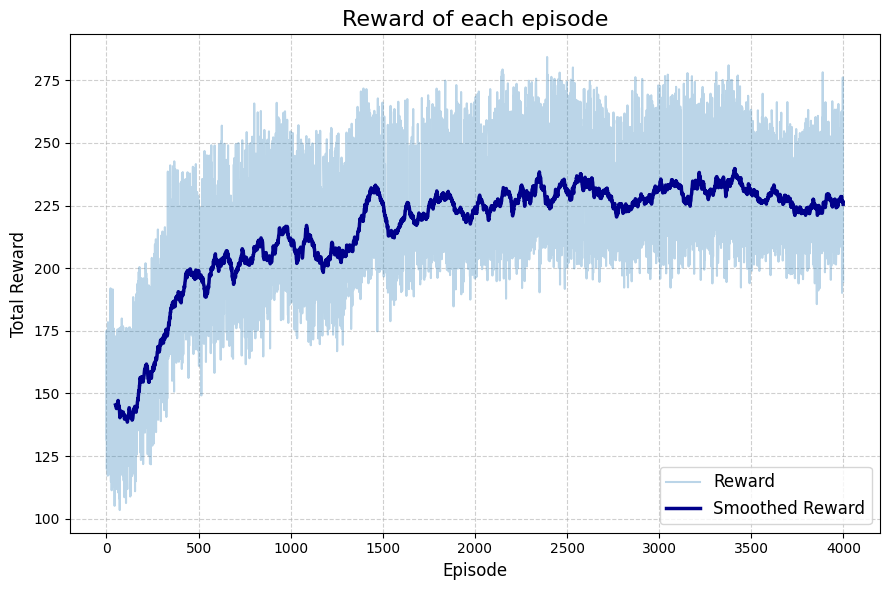

In [18]:
# ==========================================
# 6. 繪製並儲存訓練學習曲線
# ==========================================
def plot_learning_curve(reward_history, window_size=30, save_path="ppo_learning_curve.png"):
    print("-" * 60)
    print("正在繪製訓練學習曲線...")
    
    plt.figure(figsize=(9, 6))
    
    # 1. 繪製原始 Reward (使用較淺的顏色，作為背景雜訊參考)
    plt.plot(reward_history, alpha=0.3, color='#1f77b4', label='Reward')
    
    # 2. 計算並繪製移動平均線 (Moving Average)
    if len(reward_history) >= window_size:
        # 使用卷積計算平滑的移動平均
        moving_avg = np.convolve(reward_history, np.ones(window_size)/window_size, mode='valid')
        # 產生對應的 X 軸座標 (平滑線會因為 window_size 往後平移)
        x_vals = np.arange(window_size - 1, len(reward_history))
        
        # 繪製平滑趨勢線 (使用較粗、對比強烈的顏色)
        plt.plot(x_vals, moving_avg, color='darkblue', linewidth=2.5, label=f'Smoothed Reward')
        
    # 3. 圖表美化與標籤
    # plt.title('PPO Training Performance', fontsize=15, fontweight='bold')
    plt.title('Reward of each episode', fontsize=16)
    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Total Reward', fontsize=12)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    
    # 4. 儲存與顯示
    plt.savefig(save_path, dpi=300)
    print(f"學習曲線圖表已儲存至: {save_path}")
    plt.show()

# 呼叫函數畫圖，傳入剛剛訓練收集的 reward_history
plot_learning_curve(reward_history, window_size=50)

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 確保設備設定與訓練時一致
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 7. 載入模型並進行推論測試 (Inference)
# ==========================================
def test_trained_ppo_model(env, model_path, target_type="max_energy", steps=10):
    print("=" * 70)
    print(f"載入模型進行測試 | 目標: {target_type}")
    print("=" * 70)
    
    # 1. 實例化空的 Actor-Critic 網路
    state_dim = env.state_dim
    action_dims = env.action_dims
    policy = PPOActorCritic(state_dim, action_dims).to(device)
    
    # 2. 載入訓練好的權重
    try:
        policy.load_state_dict(torch.load(model_path, map_location=device))
        print(f"成功載入模型權重: {model_path}\n")
    except Exception as e:
        print(f"載入模型失敗，請確認路徑與架構: {e}")
        return
        
    # 3. 切換到評估模式
    policy.eval()
    
    # 4. 重置環境 (這會隨機生成初始狀態)
    state = env.reset(target_type=target_type)

    # ---------------------------------------------------------
    # 擷取「初始狀態」的參數、力學分數與應力應變曲線
    # ---------------------------------------------------------
    init_weave = env.weave_options[env.cur_weave_idx]
    init_resin = env.resin_options[env.cur_resin_idx]
    init_fiber = env.fiber_options[env.cur_fiber_idx]
    init_geo = env.cur_geo_real.copy()
    init_score = env._calculate_physics_score()
    
    # 呼叫預測模型以取得初始曲線
    init_geo_dict = {"angle": init_geo[0], "width": init_geo[1], "height": init_geo[2]}
    init_result = env.predictor.predict(init_weave, init_geo_dict, init_resin, init_fiber)
    init_stress = init_result["plastic"][0::2] if "plastic" in init_result else []
    init_strain = init_result["plastic"][1::2] if "plastic" in init_result else []

    # 準備變數來記錄「最佳化狀態」
    opt_weave, opt_resin, opt_fiber = None, None, None
    opt_geo = None
    opt_score = -float('inf')
    opt_stress, opt_strain = [], []

    # ---------------------------------------------------------
    # 5. 開始推論迴圈
    # ---------------------------------------------------------
    for step in range(1, steps + 1):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        # --- 確定性策略 (Deterministic Action) ---
        with torch.no_grad():
            actor_features = policy.actor_feature(state_tensor)
            
            weave_idx = torch.argmax(policy.head_weave(actor_features), dim=1).item()
            resin_idx = torch.argmax(policy.head_resin(actor_features), dim=1).item()
            fiber_idx = torch.argmax(policy.head_fiber(actor_features), dim=1).item()
            geo_norm = policy.head_geo_mean(actor_features).squeeze(0).cpu().numpy()
            
        action_dict = {
            'weave': weave_idx,
            'resin': resin_idx,
            'fiber': fiber_idx,
            'geo': geo_norm
        }
        
        # 執行動作並觀察結果
        next_state, reward, done, info = env.step(action_dict)
        
        real_geo = info['real_geo']
        raw_score = info['raw_score']
        
        weave_name = env.weave_options[weave_idx]
        resin_name = env.resin_options[resin_idx]
        fiber_name = env.fiber_options[fiber_idx]
        
        print(f"Step {step:2d} | 總分: {raw_score:.4e} | "
              f"編織: {weave_name:5s} | 樹脂: {resin_name:6s} | 纖維: {fiber_name:5s} | "
              f"幾何: [{real_geo[0]:4.1f}°, 寬:{real_geo[1]:4.2f}, 高:{real_geo[2]:4.2f}]")
              
        # 如果當前步驟的分數是目前最高的，更新最佳化記錄
        if raw_score > opt_score:
            opt_score = raw_score
            opt_weave, opt_resin, opt_fiber = weave_name, resin_name, fiber_name
            opt_geo = real_geo.copy()
            
            # 取得最佳化狀態的應力應變曲線
            opt_geo_dict = {"angle": opt_geo[0], "width": opt_geo[1], "height": opt_geo[2]}
            opt_result = env.predictor.predict(opt_weave, opt_geo_dict, opt_resin, opt_fiber)
            opt_stress = opt_result["plastic"][0::2] if "plastic" in opt_result else []
            opt_strain = opt_result["plastic"][1::2] if "plastic" in opt_result else []

        state = next_state
        if done:
            break

    # ==========================================
    # 6. 在 VSCode 終端機輸出比較表格
    # ==========================================
    improvement = ((opt_score - init_score) / (init_score + 1e-9)) * 100

    print("\n" + "="*70)
    print(f"{'Optimization Results (' + target_type + ')':^70}")
    print("="*70)
    print(f"{'Parameter':<18} | {'Initial State':<22} | {'Optimized State':<22}")
    print("-" * 70)
    print(f"{'Weave Style':<18} | {init_weave:<22} | {opt_weave:<22}")
    print(f"{'Fiber Material':<18} | {init_fiber:<22} | {opt_fiber:<22}")
    print(f"{'Resin Material':<18} | {init_resin:<22} | {opt_resin:<22}")
    print(f"{'Weave Angle (°)':<18} | {init_geo[0]:<22.1f} | {opt_geo[0]:<22.1f}")
    print(f"{'Width':<18} | {init_geo[1]:<22.2f} | {opt_geo[1]:<22.2f}")
    print(f"{'Height':<18} | {init_geo[2]:<22.2f} | {opt_geo[2]:<22.2f}")
    print("-" * 70)
    print(f"{'Performance':<18} | {init_score:<22.4e} | {opt_score:<22.4e}")
    print(f"{'Improvement (%)':<18} | {'-':<22} | {improvement:+.2f} %")
    print("="*70 + "\n")

    # ==========================================
    # [新增] 定義輔助函數：計算 3 個目標的力學性質
    # ==========================================
    def calc_metrics(stress, strain):
        energy, stiffness, yield_str = 0.0, 0.0, 0.0
        if len(strain) > 1:
            energy = np.trapezoid(stress, strain)
            stiffness = (stress[1] - stress[0]) / (strain[1] - strain[0])
            try:
                # 確保外部有 find_smart_yield_point 函數
                y_str, _, _, _ = find_smart_yield_point(stress, strain)
                if y_str: yield_str = y_str
            except:
                yield_str = 0.0
        return energy, stiffness, yield_str

    # ==========================================
    # 7. 繪製初始與最佳化狀態的應力應變曲線
    # ==========================================
    if len(init_strain) > 0 and len(opt_strain) > 0:
        plt.figure(figsize=(8, 6))
        
        # 初始狀態曲線 (紅色虛線)
        plt.plot(init_strain, init_stress, color='red', linestyle='--', linewidth=2, label='Initial Design')
        
        # 最佳化狀態曲線 (深藍色實線)
        plt.plot(opt_strain, opt_stress, color='navy', linestyle='-', linewidth=2.5, label='Optimized Design')
        
        # ---------------------------------------------------------
        # [修改] 計算力學性質，並根據當前最佳化目標選擇顯示數值與行列轉換排版
        # ---------------------------------------------------------
        init_e, init_s, init_y = calc_metrics(init_stress, init_strain)
        opt_e, opt_s, opt_y = calc_metrics(opt_stress, opt_strain)
        
        # 判斷當前目標並提取對應數值與名稱
        if target_type == "max_energy":
            target_name = "Strain Energy Density"
            val_init = init_e
            val_opt = opt_e
        elif target_type == "max_stiffness":
            target_name = "Stiffness"
            val_init = init_s
            val_opt = opt_s
        elif target_type == "max_yield":
            target_name = "Yield Strength"
            val_init = init_y
            val_opt = opt_y
        else:
            target_name = "Unknown Metric"
            val_init = 0.0
            val_opt = 0.0
            
        # 計算差距百分比
        val_diff = ((val_opt - val_init) / (val_init + 1e-9)) * 100
        
        # 利用固定長度排版，不使用縮寫，並將行列交換 (垂直排列)
        text_str = (
            f"{'State':<12} | {target_name}\n"
            f"{'-'*32}\n"
            f"{'Initial':<12} | {val_init:.2e}\n"
            f"{'Optimized':<12} | {val_opt:.2e}\n"
            f"{'Difference':<12} | {val_diff:>+.2f}%"
        )
        
        # 將文字方塊放置在左上角，並強制設定 family='monospace' 以確保對齊
        plt.gca().text(0.03, 0.95, text_str, transform=plt.gca().transAxes, 
                       fontsize=12, verticalalignment='top', family='monospace',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        
        plt.title(f'{target_name} Optimization ', fontsize=16)
        plt.xlabel('Strain', fontsize=12)
        plt.ylabel('Stress', fontsize=12)
        plt.legend(fontsize=12, loc='lower right')
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
        
        plt.tight_layout()
        plt.show()
    else:
        print("無法取得應力應變曲線，可能預測模型未正確回傳 'plastic' 資料。")


--- 測試 1：最大化應變能 (Energy) ---
載入模型進行測試 | 目標: max_energy
成功載入模型權重: ppo_best_model.pth

Step  1 | 總分: 8.8261e+03 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.94, 高:0.11]
Step  2 | 總分: 8.8186e+03 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.94, 高:0.11]
Step  3 | 總分: 8.8187e+03 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.94, 高:0.11]
Step  4 | 總分: 8.8187e+03 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.94, 高:0.11]
Step  5 | 總分: 8.8187e+03 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.94, 高:0.11]

                  Optimization Results (max_energy)                   
Parameter          | Initial State          | Optimized State       
----------------------------------------------------------------------
Weave Style        | plain                  | satin                 
Fiber Material     | E-glass                | Carbon                
Resin Material     | CEL-400                | ELER-8-130            
Weave Angl

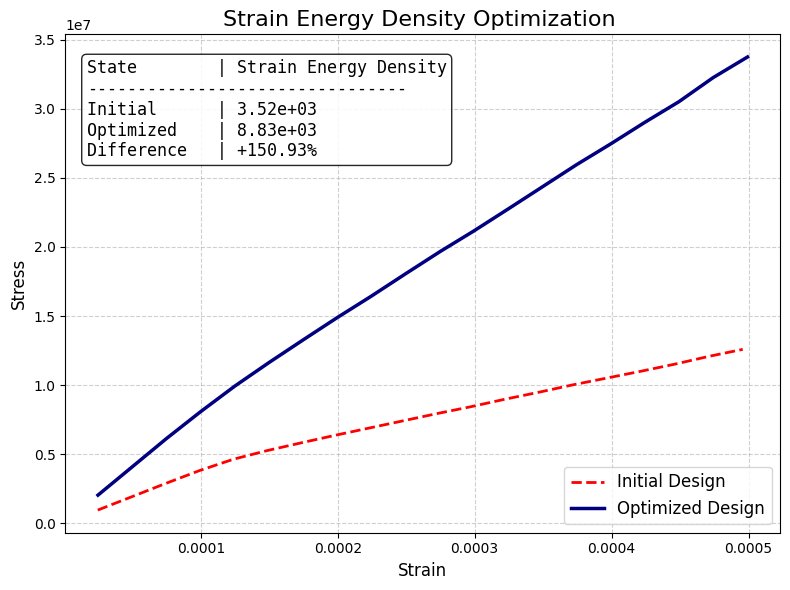

In [24]:
print("\n--- 測試 1：最大化應變能 (Energy) ---")
test_trained_ppo_model(env, model_path="ppo_best_model.pth", target_type="max_energy", steps=5)


--- 測試 2：最大化剛性 (Stiffness) ---
載入模型進行測試 | 目標: max_stiffness
成功載入模型權重: ppo_best_model.pth

Step  1 | 總分: 8.1599e+10 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]
Step  2 | 總分: 8.1679e+10 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]
Step  3 | 總分: 8.1679e+10 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]
Step  4 | 總分: 8.1679e+10 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]
Step  5 | 總分: 8.1679e+10 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]

                 Optimization Results (max_stiffness)                 
Parameter          | Initial State          | Optimized State       
----------------------------------------------------------------------
Weave Style        | twill                  | satin                 
Fiber Material     | Carbon                 | Carbon                
Resin Material     | ELER-8-130             | ELER-8-130            
Weave

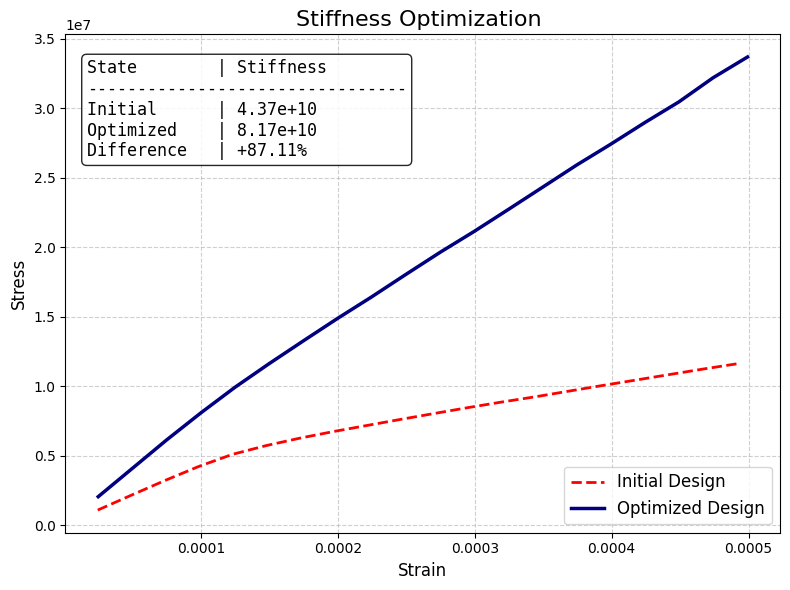

In [29]:
print("\n--- 測試 2：最大化剛性 (Stiffness) ---")
test_trained_ppo_model(env, model_path="ppo_best_model.pth", target_type="max_stiffness", steps=5)


--- 測試 3：最大化降伏應力 (Yield) ---
載入模型進行測試 | 目標: max_yield
成功載入模型權重: ppo_best_model.pth

Step  1 | 總分: 1.0629e+07 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.94, 高:0.11]
Step  2 | 總分: 1.0632e+07 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]
Step  3 | 總分: 1.0632e+07 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]
Step  4 | 總分: 1.0632e+07 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]
Step  5 | 總分: 1.0632e+07 | 編織: satin | 樹脂: ELER-8-130 | 纖維: Carbon | 幾何: [30.3°, 寬:0.95, 高:0.11]

                   Optimization Results (max_yield)                   
Parameter          | Initial State          | Optimized State       
----------------------------------------------------------------------
Weave Style        | plain                  | satin                 
Fiber Material     | E-glass                | Carbon                
Resin Material     | Plaskon SMT-B-1F       | ELER-8-130            
Weave Angle

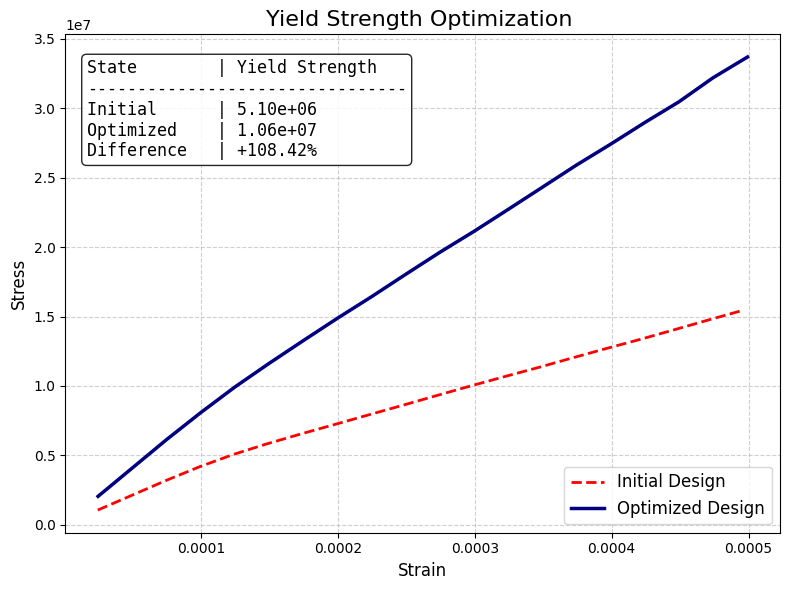

In [22]:
print("\n--- 測試 3：最大化降伏應力 (Yield) ---")
test_trained_ppo_model(env, model_path="ppo_best_model.pth", target_type="max_yield", steps=5)